
# Hypothesis Testing —

**Libraries used:** `numpy`, `scipy`, `pandas`, `matplotlib`, `random`  
**Significance level:** unless stated otherwise, use **α = 0.05**.


In [ ]:

# Imports
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import random


np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.precision", 4)



## Exercise 1 — AB-testing: Mom Smoker

**Goal.** Using the dataset `data/baby.csv`, to quantify whether **maternal smoking** is associated with **lower birth weight**.




In [ ]:
from google.colab import files
baby_data = files.upload()

Saving baby.csv to baby (1).csv


In [ ]:
df = pd.read_csv('baby.csv')

In [ ]:
df.shape

(1174, 6)

In [ ]:
#Print the header of the dataframe to see all the columns
df.head()

,Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
0,120,284,27,62,100,False
1,113,282,33,64,135,False
2,128,279,28,64,115,True
3,108,282,23,67,125,True
4,136,286,25,62,93,False


In [ ]:
#Select only the columns of interest
df = df[['Maternal Smoker', 'Birth Weight']]

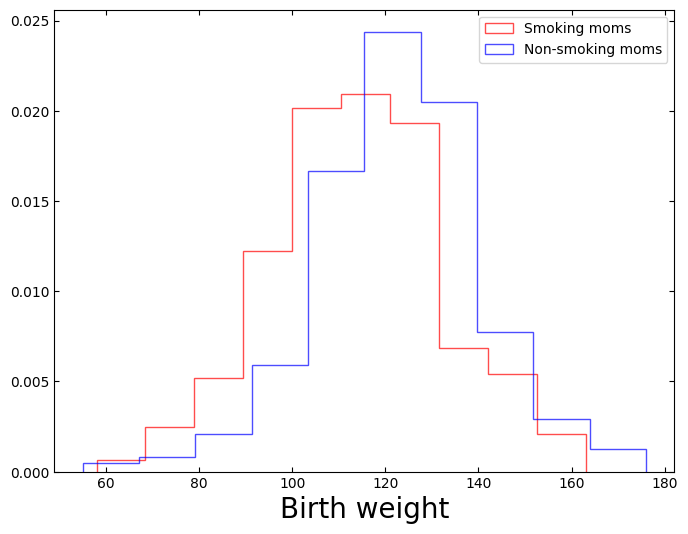

In [ ]:
# Plot the distribution for smoker and non smoker
fig, ax1 = plt.subplots(figsize=(8,6), facecolor='w', edgecolor='k')


ax1.hist(df[df['Maternal Smoker']==True]['Birth Weight'].values,histtype='step',density=True,color='r', alpha=0.7,lw=3,label='Smoking moms')
ax1.hist(df[df['Maternal Smoker']==False]['Birth Weight'].values,histtype='step',density=True,color='b', alpha=0.7,lw=3,label='Non-smoking moms')
ax1.set_xlabel('Birth weight',fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=10,direction='in',right='on',top='on')
ax1.legend()

plt.show()

**Null hypothesis:** There is no difference between the two sample means (difference=0)

**Alternative hypothesis:** There is a difference between the two sample means (two-tailed)



In [ ]:
smoke=df[df['Maternal Smoker']==True]['Birth Weight'].values
nonsmoke=df[df['Maternal Smoker']==False]['Birth Weight'].values
# calculate means
x1, x2 = np.mean(smoke), np.mean(nonsmoke)
# calculate standard errors
std1, std2 = np.std(smoke), np.std(nonsmoke)
# size sample
n1,n2=np.size(smoke),np.size(nonsmoke)


# Null Hypothesis = mu_1-mu_2 = 0
# Hypothesized difference (under the null hypothesis)
D = 0

# Set the significance level
alpha = 0.05

# Calculate the test statistic (t-score)
t_score = ((x1 - x2) - D) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
print('t-Score:', np.abs(t_score))

#Degree of freedom
deg_free = ((std1**2/n1 + std2**2/n2)**2) / ((std1**2/n1)**2/(n1-1) + (std2**2/n2)**2/(n2-1))


# Calculate the critical value
t_crit = stats.t.ppf(1 - alpha/2, deg_free)
print('Critical t-Score:',t_crit)

# Compare the test statistic with the critical value
if np.abs(t_score) > t_crit:
    print("""Reject the null hypothesis.
There is a significant difference between the baby weight for smoker and non smoker mom.""")
else:
    print("""Fail to reject the null hypothesis.
There is not a significant difference between the baby weight for smoker and non smoker mom.""")

# Approach 2: Using P-value

p_value = 2 * stats.t.sf(abs(t_score), deg_free)   # two-sided

print('P-Value :',p_value)

# Compare the p-value with the significance level
if p_value < alpha:
    print("""Reject the null hypothesis.
There is a significant difference between the baby weight for smoker and non smoker mom.""")
else:
    print("""Fail to reject the null hypothesis.
There is a significant difference between the baby weight for smoker and non smoker mom.""")

t-Score: 8.634634929032464
Critical t-Score: 1.9624852585766828
Reject the null hypothesis.
There is a significant difference between the baby weight for smoker and non smoker mom.
P-Value : 2.4852911627013377e-17
Reject the null hypothesis.
There is a significant difference between the baby weight for smoker and non smoker mom.


## Exercise 2 — AB-testing: Drug test

**Goal.** Using the dataset `data/bta.csv`, to quantify whether **botulinum toxin A** has different effect from **saline**

In [ ]:
from google.colab import files
bta_data = files.upload()

Saving bta.csv to bta.csv


In [ ]:
bta = pd.read_csv('bta.csv')
bta.head()
bta.shape

(31, 2)

In [ ]:
#Groupby result
bta.groupby('Group')['Result'].mean().reset_index(name='Result average')

,Group,Result average
0,Control,0.125
1,Treatment,0.600


In the treatment group, 60% of the patients had pain relief, compared to only 12.5% in the control group. None of the patients suffered any side effects.

So the indications are that botulinum toxin A did better than the saline. But the conclusion isn't yet a slam-dunk. The patients were assigned at random into the two groups, so perhaps the difference could just be due to chance?

**Null Hypothesis:** Botulinum toxin A does nothing different from saline; the difference in the two samples is just due to chance.

**Alternative Hypothesis:** The treatment does something different from the control.

In [ ]:
pop_treat = bta[bta['Group']=='Treatment'].Result.astype(int)
pop_ctrl  = bta[bta['Group']=='Control'].Result.astype(int)

n1, n2 = len(pop_treat), len(pop_ctrl)
Y1, Y2 = pop_treat.sum(), pop_ctrl.sum()
p1, p2 = Y1/n1, Y2/n2

p_pool = (Y1 + Y2) / (n1 + n2)
se = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))

z_stat = (p1 - p2) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

se_unpooled = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
zcrit = stats.norm.ppf(0.975)

print(f"n1={n1:.3f}, p2={n2:.3f}")
print(f"Y1={Y1:.3f}, Y2={Y2:.3f}")
print(f"p1={p1:.3f}, p2={p2:.3f}")
print(f"z={z:.3f}, zcrit={zcrit:.3f}")
print(f"alpha={alpha:.4f},p-value={p_value:.4f}")


# interpret via critical value
if abs(z_stat) <= zcrit:
 print('Accept null hypothesis that the means are equal, treatment does not work.')
else:
 print('Reject the null hypothesis that the means are not equal, treatment works')
# interpret via p-value
if p_value > alpha:
 print('Accept null hypothesis that the means are equal, treatment does not work.')
else:
 print('Reject the null hypothesis that the means are not equal, treatment works.')

n1=15.000, p2=16.000
Y1=9.000, Y2=2.000
p1=0.600, p2=0.125
z=2.762, zcrit=1.960
alpha=0.0500,p-value=0.0057
Reject the null hypothesis that the means are not equal, treatment works
Reject the null hypothesis that the means are not equal, treatment works.


# Exercises 3

We will use the following summary statistics:

- **Males (X)**: $(n_x = 34,\ \bar{x} = 105.5,\ s_x = 20.1)$  
- **Females (Y)**: $(n_y = 29,\ \bar{y} = 90.9,\ s_y = 12.2)$


**Is the mean fastest speed driven by male college students different than the mean fastest speed driven by female college students?**

In [ ]:

nx, xbar, sx = 34, 105.5, 20.1
ny, ybar, sy = 29, 90.9, 12.2
alpha = 0.05


In [ ]:
# Null Hypothesis = mu_1-mu_2 = 0
# Hypothesized difference (under the null hypothesis)
D = 0

# Calculate the test statistic (t-score)
t_score = ((xbar - ybar) - D) / np.sqrt((sx**2 / nx) + (sy**2 / ny))
print('t-Score:', np.abs(t_score))

#Degree of freedom
deg_free = ((sx**2/nx + sy**2/ny)**2) / ((sx**2/nx)**2/(nx-1) + (sy**2/ny)**2/(ny-1))


# Calculate the critical value
t_crit = stats.t.ppf(1 - alpha/2, deg_free)
print('Critical t-Score:',t_crit)

# Compare the test statistic with the critical value
if np.abs(t_score) > t_crit:
    print("""Reject the null hypothesis.
There is a significant difference between the fastest speed driven by male college students and female. """)
else:
    print("""Fail to reject the null hypothesis.
There is not a significant difference between the fastest speed driven by male college students and female.""")

# Approach 2: Using P-value

p_value = 2 * stats.t.sf(abs(t_score), deg_free)   # two-sided

print('P-Value :',p_value)

# Compare the p-value with the significance level
if p_value < alpha:
    print("""Reject the null hypothesis.
There is a significant difference between the fastest speed driven by male college students and female. """)
else:
    print("""Fail to reject the null hypothesis.
There is not a significant difference between the fastest speed driven by male college students and female.""")

t-Score: 3.539452614638691
Critical t-Score: 2.0036650755229175
Reject the null hypothesis.
There is a significant difference between the fastest speed driven by male college students and female. 
P-Value : 0.0008198328571593819
Reject the null hypothesis.
There is a significant difference between the fastest speed driven by male college students and female. 



**Is there sufficient evidence at the alpha=0.05  level to conclude that the variance of the fastest speed driven by male college students differs from the variance of the fastest speed driven by female college students?**




In [ ]:

# F-test using summary stats
s1_sq, s2_sq = sx**2, sy**2

F = s2_sq / s1_sq
df1, df2 = ny - 1, nx - 1

# Critical values for two-tailed test
Fcrit_right = stats.f.ppf(1 - alpha/2, df1, df2)
Fcrit_left  = stats.f.ppf(alpha/2, df1, df2)

print(f"F = {F:.4f} with df1={df1}, df2={df2}")
print(f"Fcrit_left = {Fcrit_left:.4f}, Fcrit_right = {Fcrit_right:.4f}")



print(f"F = {F:.4f},Fcrit_left = {Fcrit_left:.4f},,Fcrit_right = {Fcrit_right:.4f}")

# Compare the test statistic with the critical value
if F < Fcrit_left or F > Fcrit_right:
    print("""Reject the null hypothesis.
There is a significant difference between the variance speed driven by male college students and female. """)
else:
    print("""Fail to reject the null hypothesis.
There is not a significant difference between the variance speed driven by male college students and female.""")

# Approach 2: Using P-value

p_left  = stats.f.cdf(F, df1, df2)
p_right = 1 - stats.f.cdf(F, df1, df2)
p_value = 2 * min(p_left, p_right)
print('P-Value :',p_value)

# Compare the p-value with the significance level
if p_value < alpha:
    print("""Reject the null hypothesis.
There is a significant difference between the variance speed driven by male college students and female. """)
else:
    print("""Fail to reject the null hypothesis.
There is not a significant difference between the variance speed driven by male college students and female.""")


F = 0.3684 with df1=28, df2=33
Fcrit_left = 0.4787, Fcrit_right = 2.0441
F = 0.3684,Fcrit_left = 0.4787,,Fcrit_right = 2.0441
Reject the null hypothesis.
There is a significant difference between the variance speed driven by male college students and female. 
P-Value : 0.008568585406633605
Reject the null hypothesis.
There is a significant difference between the variance speed driven by male college students and female. 



## Exercise 4 — Helmet Manufacturer:
A manufacturer of hard safety hats for construction workers is concerned about the mean and the variation of the forces its helmets transmits to wearers when subjected to an external force. The manufacturer has designed the helmets so that the mean force transmitted by the helmets to the workers is 800 pounds (or less) with a standard deviation to be less than 40 pounds. Tests were run on a random sample of n = 40 helmets, and the sample mean and sample standard deviation were found to be 825 pounds and 48.5 pounds, respectively.
Do the data provide sufficient evidence, at the alpha=0.05 level, to conclude that the population standard deviation exceeds 40 pounds?

Here we only test the **variance requirement**:
- $(H_0: \sigma = 40)$  
- $(H_1: \sigma > 40)$  (right-tailed test)




In [ ]:

n, s, sigma0 = 40, 48.5, 40.0
df = n - 1

# Test statistic
chi2 = (df * s**2) / (sigma0**2)

# One-sided test (H1: sigma > sigma0)
chi2_crit = stats.chi2.ppf(1 - alpha, df)
p_value = 1 - stats.chi2.cdf(chi2, df)
alpha=0.05

print(f"chi2 = {chi2:.4f}, df = {df}")
print(f"Critical chi2 (alpha=0.05) = {chi2_crit:.4f}")
print(f"p-value = {p_value:.6f}")

if chi2 > chi2_crit:
    print("Reject H0: sufficient evidence, at the alpha=0.05 level, to conclude that the population standard deviation exceeds 40 pounds")
else:
    print("Fail to reject H0:")

if p_value < alpha:
    print("Reject H0: sufficient evidence, at the alpha=0.05 level, to conclude that the population standard deviation exceeds 40 pounds")
else:
    print("Fail to reject H0:")

chi2 = 57.3361, df = 39
Critical chi2 (alpha=0.05) = 54.5722
p-value = 0.029284
Reject H0: sufficient evidence, at the alpha=0.05 level, to conclude that the population standard deviation exceeds 40 pounds
Reject H0: sufficient evidence, at the alpha=0.05 level, to conclude that the population standard deviation exceeds 40 pounds



## Exercise 5 — Children’s Home: Are boys underfed?

Boys of a certain age are known to have a mean (µ) weight of 85 pounds. A complaint is made that the boys living in a municipal children's home are underfed. As one bit of evidence, n=25 boys (of the same age) are weighed and found to have a mean weight of <x> = 80.94 pounds. It is known that the population standard deviation  is 11.6 pounds. Based on the available data, what should be concluded concerning the complaint?




In [ ]:

mu0, xbar, sigma, n = 85.0, 80.94, 11.6, 25
alpha=0.05
# z statistic
z = (xbar - mu0) / (sigma / np.sqrt(n))

# Critical value (left-tailed)
zcrit = stats.norm.ppf(alpha)

# p-value (left-tailed test)
p_value = stats.norm.cdf(z)

print(f"z = {z:.4f}")
print(f"Critical z (alpha=0.05, left-tailed) = {zcrit:.4f}")
print(f"p-value = {p_value:.6f}")

if z < zcrit:
    print("Reject H0: boys appear underfed (mean weight < 85).")
else:
    print("Fail to reject H0: insufficient evidence that boys are underfed.")

if p_value < alpha:
    print("Reject H0: boys appear underfed (mean weight < 85).")
else:
    print("Fail to reject H0: insufficient evidence that boys are underfed.")

z = -1.7500
Critical z (alpha=0.05, left-tailed) = -1.6449
p-value = 0.040059
Reject H0: boys appear underfed (mean weight < 85).
Reject H0: boys appear underfed (mean weight < 85).
